In [1]:
import pandas as pd 
data = pd.read_csv(r"C:\Users\NIHAL-PC\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.DataFrame(data)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [2]:
#Basic Analysis of data with relevant transformation 







In [3]:
#Checkind Data Type 
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [4]:
#Changing data type of Total Charges to float from str 
#df['TotalCharges'].unique().tolist()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

# errors='raise' (default): Throws an error if any value cannot be converted.
# errors='coerce': Converts invalid values to NaN.
# errors='ignore' (deprecated in recent pandas versions): Leaves the original values unchanged if conversion fails.

#df.isnull().sum()  #11 NAN values generated so drop null values from total charges 
df = df.dropna(subset = ['TotalCharges'])

In [5]:
#Dropping Customer ID (Not needed)
df  = df.drop('customerID',axis = 1)

In [6]:
#Checking Shape of data 
df.shape 

(7032, 20)

In [7]:
#Exploratory Data Analysis 






In [8]:
# Describing numerical columns 
num_cols = ['tenure','MonthlyCharges','TotalCharges']
df[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [9]:
#Total Charges 

df['TotalCharges'].describe()
# On an average total charges extracted from a customer = 2283 $
# Min Charge from a customer = 18 $
# Max Charge from a customer = 8684 $
# 25 % , 50% , 75% customers paid less than or equal to  401 $, 1397 $ , 3794 $ respectively

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

In [10]:
#Internet Service 

p = df.groupby('InternetService')['Churn'].count()
# Fiber optic is the most common internet service, with 3,096 customers.
# DSL is the second most common internet service, used by 2,416 customers.
# 1,520 customers do not have an internet service.

pp = df[df['Churn']=='Yes'].groupby('InternetService')['Churn'].count()
# Fiber optic has the highest number of churned customers, with 1,297 customers.
# DSL has 459 churned customers.
# Customers with no internet service have the lowest churn count, with 113 customers.

churn_rate = ((pp / p) * 100).round(2)
#Fiber optic has the highest churn rate at 41.89%, 
#indicating that customers using Fiber optic are the most likely to churn.


#Those who Churn and use Fibre Optic are all Phone Service user 
#Those who do not take online security have higher Churning as Fibre user
#Those who didnt took Online Backup churn more
#Those who have ever took Tech Support churned less 
#Month to Month users are significantly more than any other contract 

x = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

filtered = df[
    (df['Churn'] == 'Yes') &
    (df['InternetService'] == 'Fiber optic')
]

#for col in x:
    #print(f"\n{col}")
    #print(filtered[col].value_counts())

In [11]:
#Gender & Senior Citizen and Churn 

#Non senior Citizens Churn more than Old and both Male and Female churn almost in the same number 
#that means gender has zero implication on Churning
e = df[df['Churn']=='Yes'].groupby(['gender','SeniorCitizen'])['Churn'].count()


In [12]:
#Churn who Streams TV and Streams Movies 
f = df[df['Churn']=='Yes'].groupby(['StreamingTV','StreamingMovies'])['Churn'].count().sort_values(ascending=False).reset_index()

# Churning is taking place of those who neither streamTV nor StreamMovies
# or those who takes both of the services 

In [13]:
#Visulatization 






In [14]:
#How many customers genderwise , AgeWise , Partner and Depandant wise are Churned
a = df[df['Churn']=='Yes'].groupby('gender')['Churn'].count()
b = df[df['Churn']=='Yes'].groupby('SeniorCitizen')['Churn'].count()
c = df[df['Churn']=='Yes'].groupby('Partner')['Churn'].count()
d = df[df['Churn']=='Yes'].groupby('Dependents')['Churn'].count()

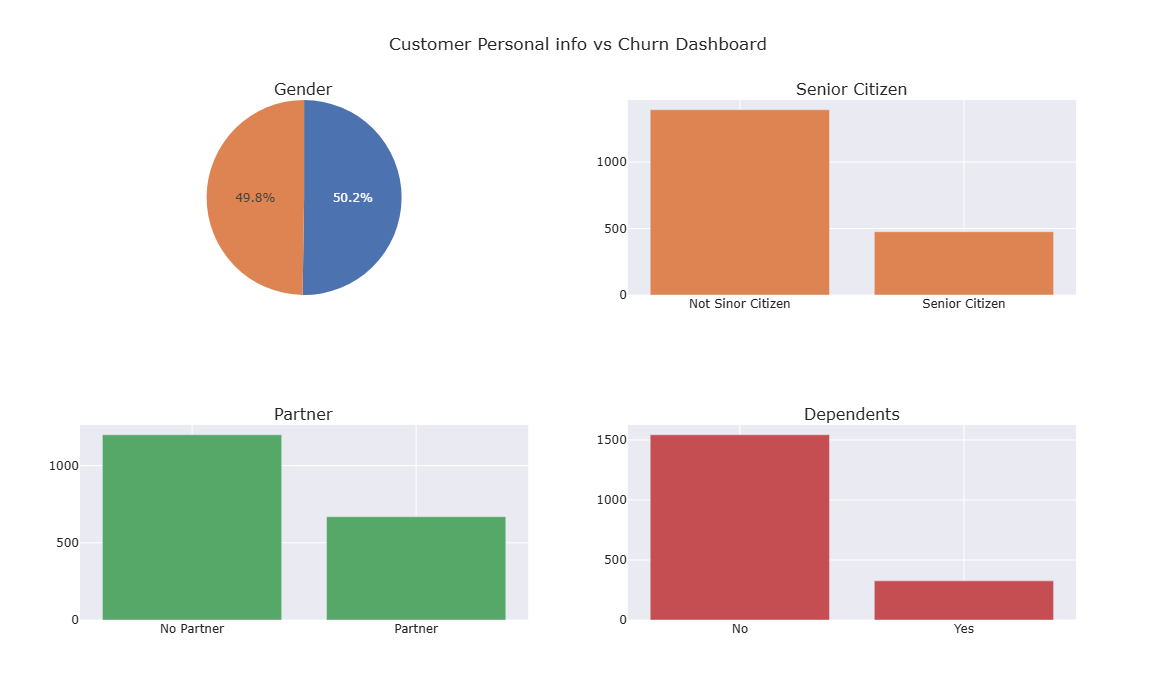

In [15]:
#Dashboard Churn vs Customer Personal info

import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Gender",
        "Senior Citizen",
        "Partner",
        "Dependents"
    ),
    specs=[                                          #Grid Structure , xy for bar , sctter , hist
        [{"type": "domain"}, {"type": "xy"}],              #domain for pie
        [{"type": "xy"}, {"type": "xy"}]
    ]
)

fig.add_trace(
    go.Pie(
        labels=a.index,
        values=a.values,
        name="Churn by Gender",
        hovertemplate="<b>%{label}</b><br>%{percent}<extra></extra>",
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Bar(x=['Not Sinor Citizen','Senior Citizen'], y=b.values, name="SeniorCitizen"),
    row=1, col=2
)

fig.add_trace(
    go.Bar(x=['No Partner','Partner'], y=c.values, name="Partner"),
    row=2, col=1
)

fig.add_trace(
    go.Bar(x=d.index, y=d.values, name="Dependents"),
    row=2, col=2
)

# Layout customization
fig.update_layout(
    title="Customer Personal info vs Churn Dashboard",
    height=700,
    width=1100,
    showlegend=False,
    template="seaborn",
)
#Pie
fig.update_traces(
    hovertemplate="<b>%{label}</b><br>Count: %{value}<br>Percentage: %{percent}<extra></extra>",
    selector=dict(type="pie")
)

# Bars
fig.update_traces(
    hovertemplate="<b>%{x}</b><br>Count: %{y}<extra></extra>",
    selector=dict(type="bar")
)

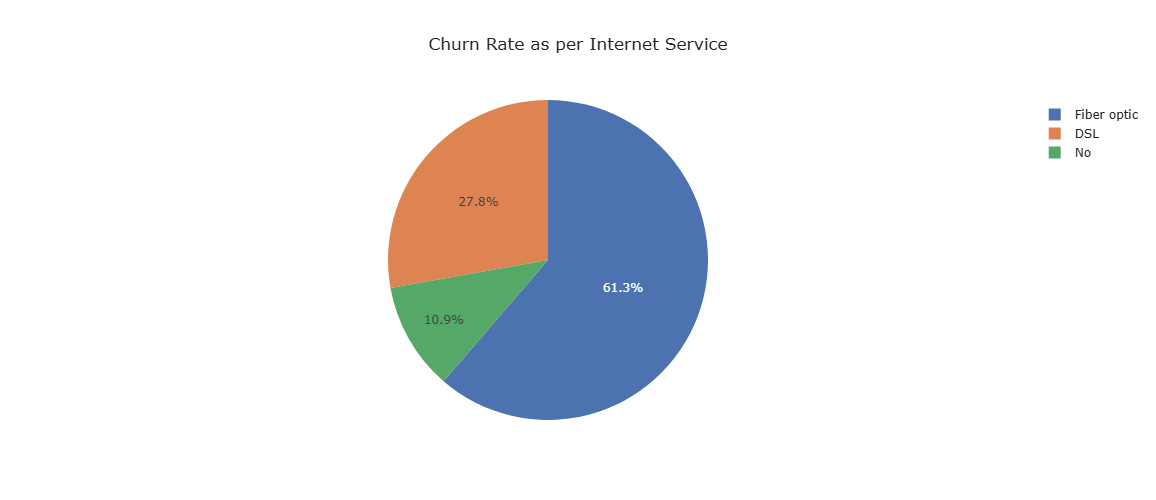

In [16]:
#Churn Rate and Internet Service 
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(
    go.Pie(
        labels=churn_rate.index,
        values=churn_rate.values,
        name="Churn by Gender"
    )
)
fig.update_layout(
    title = "Churn Rate as per Internet Service",
    template = "seaborn",
    width = 1100,
    height = 500
)
fig.show()

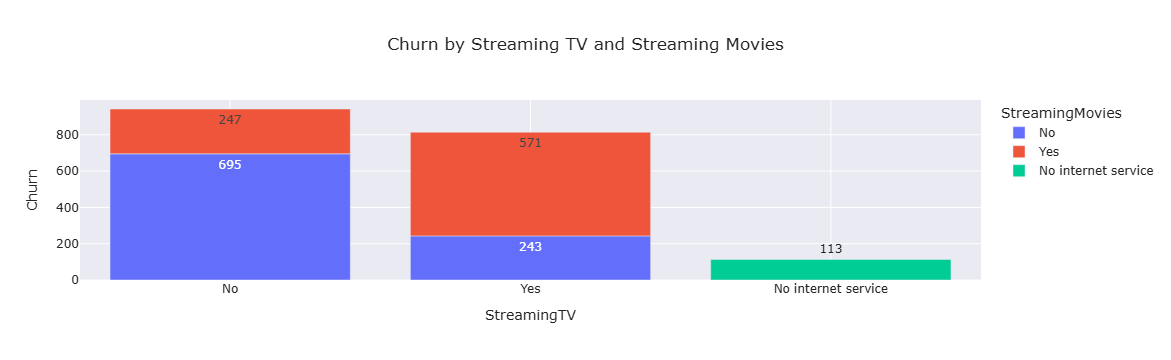

In [17]:
#Churn by Streaming TV and Streaming Movies

import plotly.express as px

fig = px.bar(
    f,
    x="StreamingTV",
    y="Churn",
    color="StreamingMovies",
    text="Churn",
    title="Churn by Streaming TV and Streaming Movies"
)

fig.update_layout(template="seaborn")

fig.show()

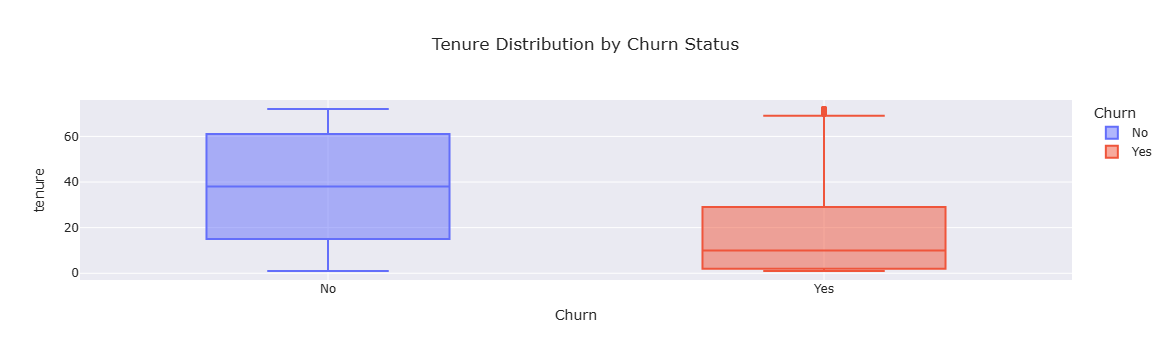

In [18]:
#Does longer tenure reduce churn?
#THOSE WE ARE LEAVING ARE HAVING AVEAGE TENURE OF JUST 10 DAYS AND 75% CUSTOMERS THOSE WHO LEFT ARE <=29 DAYS TENURE 
#YES LONGER TENURE REDUCE THE CHURN 
import plotly.express as px

fig = px.box(
    df,
    x="Churn",
    y="tenure",
    color="Churn",
    title="Tenure Distribution by Churn Status"
)

fig.update_layout(template="seaborn")
fig.show()

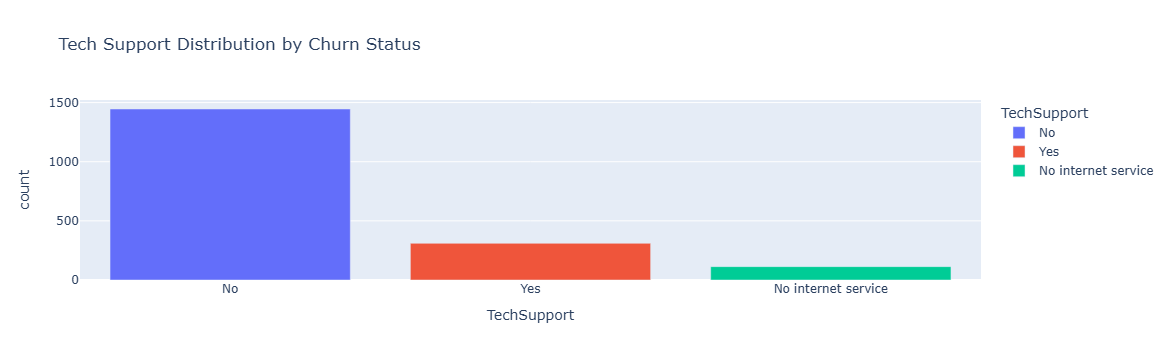

In [19]:
#Do customers with tech support churn less? Yes
aa = df[df["Churn"]=="Yes"]['TechSupport'].value_counts().reset_index()
fig = px.bar(
  aa,
  x="TechSupport",
  y="count",
  color = "TechSupport",
  title =  "Tech Support Distribution by Churn Status"
)
fig.show()

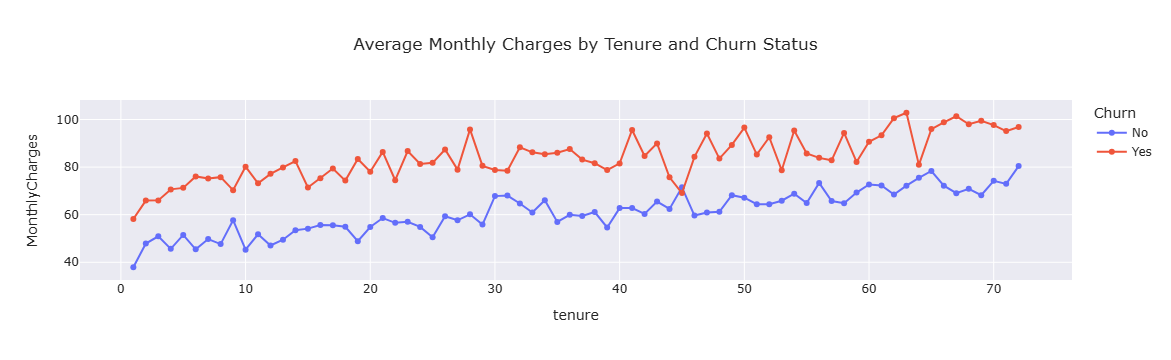

In [20]:
#Average Montly Charges trend with increasing tenure of both Churn and retained 

#Churned customers pay higher monthly charges

#Monthly charges increase slightly with tenure Customers with longer tenure tend to have slightly higher monthly charges, possibly 
#because they upgrade to premium plans or add more services over time.

#Gap between churned and retained customers 
#Even at the same tenure, churned customers usually pay noticeably more than retained customers.


import plotly.express as px

line_df = (
    df.groupby(["tenure", "Churn"])["MonthlyCharges"]
      .mean()
      .reset_index()
)

fig = px.line(
    line_df,
    x="tenure",
    y="MonthlyCharges",
    color="Churn",
    markers=True,
    title="Average Monthly Charges by Tenure and Churn Status"
)

fig.update_layout(template="seaborn")

fig.show()

In [21]:
#Label Encoding 

binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]


onehot_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

numeric_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]


from sklearn.preprocessing import LabelEncoder
import pickle

encoders = {}

for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

with open("label_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)


#One Hot encoding 

from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import pickle

# Create OneHotEncoder
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Fit and Transform
encoded = ohe.fit_transform(df[onehot_cols])

# Convert to DataFrame
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(onehot_cols),
    index=df.index
)

# Drop original categorical columns
df.drop(columns=onehot_cols, inplace=True)

# Add encoded columns
df = pd.concat([df, encoded_df], axis=1)

# Save encoder
with open("onehot_encoder.pkl", "wb") as f:
    pickle.dump(ohe, f)

In [22]:
#Scaling of numerical columns 
from sklearn.preprocessing import StandardScaler
import pickle

scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

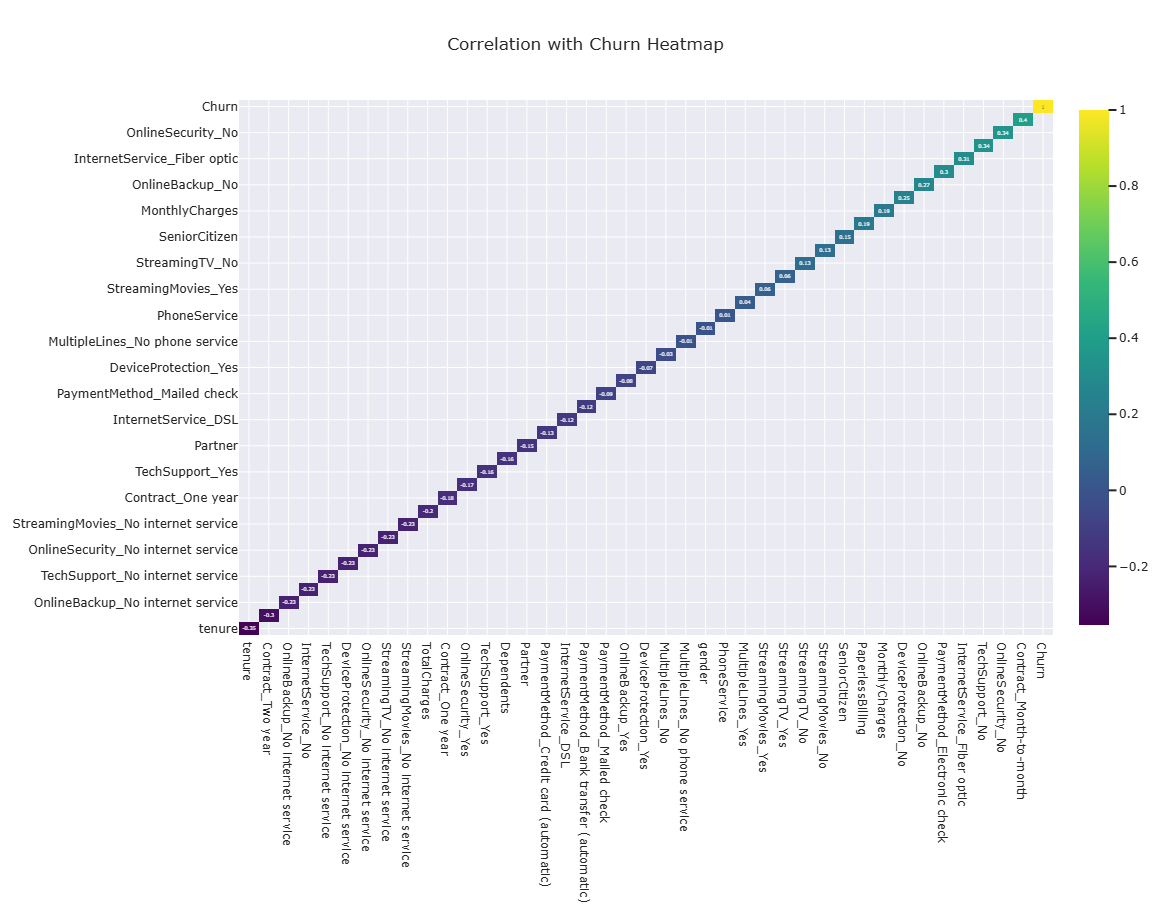

In [23]:
#Correlation with Churn 

corr_matrix = df.corr()['Churn'].sort_values(ascending=True)


fig = go.Figure(
    data=go.Heatmap(
        z=corr_matrix.values,
        x=corr_matrix.index,
        y=corr_matrix.index,
        colorscale='Viridis',
        text=round(corr_matrix, 2),
        texttemplate="%{text}"
    )
)

fig.update_layout(
    title="Correlation with Churn Heatmap",
    title_x=0.5,
    width=1200,
    height=900,
    template = "seaborn"
)

fig.show()

In [24]:
#Model Training 





In [25]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# SPLIT DATA

X = df.drop("Churn", axis=1)
y = df["Churn"]

#Saving Columns 
with open("feature_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# MODEL

svc = SVC(class_weight='balanced',probability=True)

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.1, 0.01, 1],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(
    svc,
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("\nBest Parameter and its score from gridsearchcv")
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

# EVALUATION

y_pred = best_model.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("\nChecking Accuracy of our model")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# SAVE MODEL + SCALER + COLUMNS

import pickle
with open("churn_model.pkl", "wb") as f:
    pickle.dump(best_model, f)


Best Parameter and its score from gridsearchcv
Best Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Score: 0.6267133608879238

Checking Accuracy of our model
Accuracy : 0.7306325515280739
Precision: 0.49572649572649574
Recall   : 0.7754010695187166
F1 Score : 0.6047966631908238

Confusion Matrix
[[738 295]
 [ 84 290]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [26]:
#Loading all saved files 
import pickle

with open("label_encoders.pkl", "rb") as f:
    label_encoders = pickle.load(f)

with open("onehot_encoder.pkl", "rb") as f:
    ohe = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("feature_columns.pkl", "rb") as f:
    feature_columns = pickle.load(f)

with open("churn_model.pkl", "rb") as f:
    model = pickle.load(f)

2026-06-17 13:35:44.195 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 13:35:44.933 
  command:

    streamlit run C:\Users\NIHAL-PC\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-17 13:35:44.933 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 13:35:44.934 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 13:35:44.939 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 13:35:44.940 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 13:35:44.942 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 13: